# Homework 5
## Holly Bossart
## Due 02/25/2020

## Problem 1 Solution
It is difficult to see the data points below the surface plot, so the below plot for the solution to Problem 1 is interactive so that you may click and drag to reposition the plot.

<IPython.core.display.Javascript object>


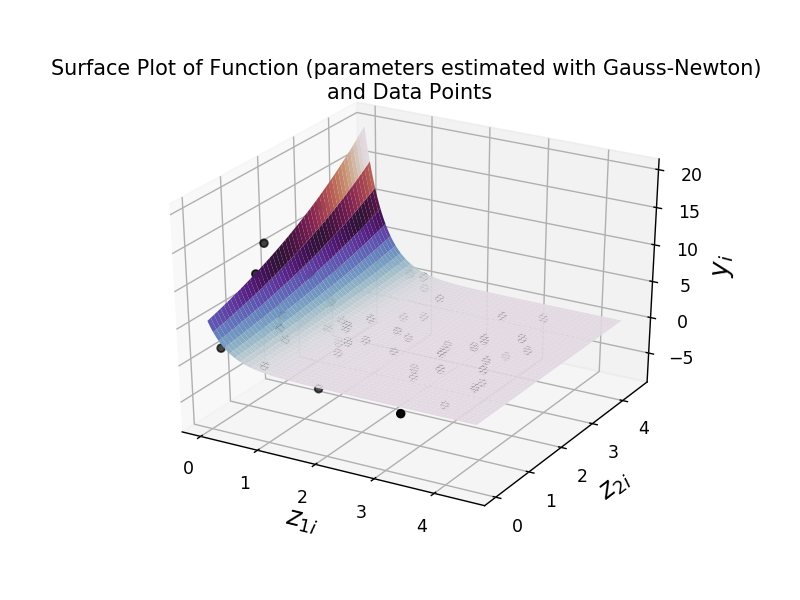

Text(0.5, 0, '$y_i$')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
%matplotlib notebook

 
data = pd.read_csv('dataHW5-1.csv',delimiter=' ', header = 0, names = ["y", "z1", "z2"])
y = data['y'].to_numpy().reshape((50,1))
z1 = data['z1'].to_numpy().reshape((50,1))
z2 = data['z2'].to_numpy().reshape((50,1))
z = data[['z1','z2']].to_numpy().reshape((50,2))

tol = 1e-6
thzero = [0.5]
thone = [0.5]
thtwo = [0.5]

def f(theta0, theta1, theta2, z1, z2):
    f = []
    for i in range(len(y)):
        val = theta0*np.exp(-theta1*z1[i] - theta2*z2[i])
        f.append(val)
    f = np.asarray(f).reshape((50,1))
    return f


def a_calc(theta0, theta1, theta2, z1, z2):
    A = []
    for i in range(len(y)):
        partth0 = np.exp(-theta1*z1[i] - theta2*z2[i])
        partth1 = theta0*(-z1[i])*np.exp(-theta1*z1[i] - theta2*z2[i])
        partth2 = theta0*(-z2[i])*np.exp(-theta1*z1[i] - theta2*z2[i])
        val = np.asarray([partth0, partth1, partth2])
        A.append(val.T)
        
    A = np.asarray(A).reshape((50,3))
    return A

def x_calc(theta0, theta1, theta2, z1, z2):
    return y - f(theta0, theta1, theta2, z1, z2)

def update_theta(theta0, theta1, theta2, max_iterations):
    values = []
    theta = np.asarray([theta0, theta1, theta2]).reshape((3,1))
    num_iters = 0
    
    while(num_iters < max_iterations):
        A = a_calc(theta0, theta1, theta2, z1, z2)
        x = x_calc(theta0, theta1, theta2, z1, z2).reshape((50,1))
        inner = inv((A.T).dot(A))
        newtheta = theta + (inner.dot(A.T)).dot(x)
        values.append(newtheta)
        theta = newtheta
        theta0 = newtheta[0]
        thzero.append(theta0)
        theta1 = newtheta[1]
        thone.append(theta1)
        theta2 = newtheta[2]
        thtwo.append(theta2)
        num_iters += 1
        
    return
        
        
update_theta(-1, 1, -1, 100)


def plot(z1, z2):
    t0 = thzero[-1]
    t1 = thone[-1]
    t2 = thtwo[-1]
    
    return (t0*np.exp(-t1*z1 - t2*z2))

zones = np.linspace(0, 4.5, 200)
ztwos = np.linspace(0, 4.5, 200)
Z1, Z2 = np.meshgrid(zones, ztwos)
Y = plot(Z1, Z2)

fig = plt.figure()
ax = fig.gca(projection='3d')
s1 = ax.plot_surface(Z1, Z2, Y, cmap = 'twilight',label = 'Fitted curve using Gauss-Newton', antialiased=True)
pts = ax.scatter3D(z1, z2, y, c= 'k', label = 'Data points')
ax.set_title('Surface Plot of Function (parameters estimated with Gauss-Newton) \nand Data Points')

ax.set_xlabel('$z_{1i}$', fontsize=15, rotation=150)
ax.set_ylabel('$z_{2i}$',fontsize=15,)
ax.set_zlabel('$y_i$', fontsize=15)

### Printed Output for Last Five Iterations of Theta
I originally ran this for 100 iterations to get the theta values. However, when they were printing out, I noticed that the values were not really changing during the last five iterations. Instead, I saw when it was changing drastically and when it stopped changing quickly, and that appears to happen around 15 iterations. Thus, for the table below, I am showing the last five iterations from the fifteen iterations I ran, though I understand it would be more accurate if the algorithm was run for a larger number of iterations.

| Iteration, t | $\mathbf{\theta^{(t)}} = (\theta_0^{(t)} \hspace{0.05in} \theta_1^{(t)}  \hspace{0.05in} \theta_2^{(t)})^{T}$       |
|--------------|------------------------------------------------------------------|
| 11           | $\begin{pmatrix} 5.7146446\\ 2.9860853\\ -0.272155\end{pmatrix}$ |
| 12           | $\begin{pmatrix}5.7146008\\2.9860662\\ -0.272157\end{pmatrix}$   |
| 13           | $\begin{pmatrix}5.7146104\\2.9860701\\ -0.272157\end{pmatrix}$   |
| 14           | $\begin{pmatrix}5.71460844\\2.9860693\\-0.272168 \end{pmatrix}$  |
| 15           | $\begin{pmatrix}5.71460888\\2.9860695\\ -0.2721569\end{pmatrix}$ |

## Problem 2 Solution

In [2]:
## Problem 2
nc = 85
ni = 196
nt = 341
pi0 = 1/3
pc0 = 1/3
pt0 = 1/3
n = nc + ni + nt


def exp_ncc(pc, pi, pt):
    return (nc*(pc**2)/(pc**2 + 2*pc*pi + 2*pc*pt))

def exp_nci(pc, pi, pt):
    return ((2*nc*pc*pi)/(pc**2 + 2*pc*pi + 2*pc*pt))

def exp_nct(pc, pi, pt):
    return ((2*nc*pc*pt)/(pc**2 + 2*pc*pi + 2*pc*pt))

def exp_nii(pc, pi, pt):
    return ((ni*(pi**2))/(pi**2 + 2*pi*pt))

def exp_nit(pc, pi, pt):
    return (2*ni*pi*pt)/(pi**2 + 2*pi*pt)

def update_pc(ncc, nci, nct):
    return ((2*ncc + nci + nct)/(2*n))

def update_pi(nii, nit, nci):
    return ((2*nii + nit + nci)/(2*n))
    
def update_pt(ntt, nct, nit):
    return ((2*ntt + nct + nit)/(2*n))


def r(pc1, pi1, pc2, pi2):
    ptemp1 = [pc1, pi1]
    ptemp1 = np.asarray(ptemp1)
    ptemp2 = [pc2, pi2]
    ptemp2 = np.asarray(ptemp2)
    num = np.linalg.norm(ptemp2 - ptemp1)
    denom = np.linalg.norm(ptemp1)
    return (num / denom)

def dc(pct, pc_hat, pct_1):
    return (pct - pc_hat)/(pct_1 - pc_hat)

def di(pit, pi_hat, pit_1):
    return (pit - pi_hat)/(pit_1 - pi_hat)

tol = 1e-6
pi_vals = [pi0]
pc_vals = [pc0]
pt_vals = [pt0]
dc_vals = ['-']
di_vals = ['-']
rvals = ['-']


def run_em():
    i = 0
    converged = False
    
    while not converged:
        ncc_val = exp_ncc(pc_vals[i], pi_vals[i], pt_vals[i])
        nci_val = exp_nci(pc_vals[i], pi_vals[i], pt_vals[i])
        nct_val = exp_nct(pc_vals[i], pi_vals[i], pt_vals[i])
        nii_val = exp_nii(pc_vals[i], pi_vals[i], pt_vals[i])
        nit_val = exp_nit(pc_vals[i], pi_vals[i], pt_vals[i])
        
        current_pi = update_pi(nii_val, nit_val, nci_val)
        current_pc = update_pc(ncc_val, nci_val, nct_val)
        current_pt = update_pt(nt, nct_val, nit_val)
        
        pi_vals.append(current_pi)
        pc_vals.append(current_pc)
        pt_vals.append(current_pt)
        i += 1
        
        rt = r(pc_vals[i-1], pi_vals[i-1], pc_vals[i], pi_vals[i])
        rvals.append(rt)
        if (rt <= tol):
            converged = True
            
    for j in range(1,i):
        dc = (pc_vals[j] - pc_vals[-1])/(pc_vals[j-1] - pc_vals[-1])
        dc_vals.append(dc)
        
        di = (pi_vals[j] - pi_vals[-1])/(pi_vals[j-1] - pi_vals[-1])
        di_vals.append(di)

run_em() 


| Iteration, $t$ | $p_c^{(t)}$           | $p_I^{(t)}$           | $R^{(t)}$               | $D_c^{(t)}$ | $D_I^{(t)}$ |
|----------------|-----------------------|-----------------------|-------------------------|-------------|-------------|
| $0$             | $0.3333333333333333$  | $0.3333333333333333$  | $-$                     | $-$         | $-$         |
| $1$              | $0.0819935691318328$  | $.23740621650589494$  | $0.5706852018868274$    | $0.0425021$ | $0.3365889$ |
| $2$              | $0.07124895222129086$ | $0.19786961442510004$ | $0.1631211984086911$    | $0.0369325$ | $0.1876545$ |
| $3$              | $0.07085204112290056$ | $0.1903603759883005$  | $0.035756018041300824$  | $0.0367268$ | $0.1777985$ |
| $4$              | $0.07083746372289564$ | $0.18902270882449176$ | $0.006586043362088232$  | $0.0367192$ | $0.1762369$ |
| $5$              | $0.07083692845123$    | $0.18878687218804827$ | $0.0011683198161134732$ | $0.0367189$ | $0.1759214$ |
| $6$              | $0.0708369087965926$  | $0.18874537476321254$ | $0.0002058004413117463$ | $0.0367189$ | $0.1757488$ |
| $7$              | $0.07083690807489428$ | $0.18873807578044915$ | $3.620521652654377e-05$ | $0.0367172$ | $0.1750866$ |
| $8$              | $0.07083690804839426$ | $0.18873679206200075$ | $6.367857166423345e-06$ | $0.0366715$ | $0.1713657$ |
| $9$              | $0.07083690804742121$ | $0.18873656628981744$ | $1.119944632912912e-06$ | $0.0354239$ | $0.1713657$ |